<a href="https://colab.research.google.com/github/gsimeon/AI-For-Beginners/blob/main/CAN_Training_Machine_Learning_Example1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

We start as normal with `pandas` and define our `DataFrame`. Our dataset from Old McDonald's farm consists of two fruits; apples and oranges. This dataset was collected over many years of weighing, sizing, and labelling fruit. The dataset consists of a three column `numpy` array of `Weight`, `Size`, and `Label`.

In [ ]:
import numpy
import pandas

columns = ["Weight", "Size", "Label"]
samples = numpy.array(
        [
            [69, 4.39, "orange"],
            [69, 4.21, "orange"],
            [65, 4.09, "orange"],
            [72, 5.85, "apple"],
            [67, 4.7, "orange"],
            [73, 5.68, "apple"],
            [70, 5.56, "apple"],
            [75, 5.11, "apple"],
            [74, 5.36, "apple"],
            [65, 4.27, "orange"],
            [73, 5.79, "apple"],
            [70, 5.47, "apple"],
            [74, 5.53, "apple"],
            [68, 4.47, "orange"],
            [74, 5.22, "apple"],
            [65, 4.48, "orange"],
            [69, 4.66, "orange"],
            [75, 5.25, "apple"],
            [67, 4.18, "orange"],
            [74, 5.5, "apple"],
            [66, 4.13, "orange"],
            [70, 4.83, "orange"],
            [69, 4.61, "orange"],
            [68, 4.08, "orange"],
            [67, 4.25, "orange"],
            [71, 5.35, "apple"],
            [67, 4.01, "orange"],
            [70, 4.22, "orange"],
            [74, 5.25, "apple"],
            [71, 5.26, "apple"],
            [73, 5.78, "apple"],
            [66, 4.68, "orange"],
            [72, 5.72, "apple"],
            [73, 5.17, "apple"],
            [68, 4.83, "orange"],
            [69, 4.11, "orange"],
            [69, 4.76, "orange"],
            [74, 5.48, "apple"],
            [70, 5.59, "apple"],
            [73, 5.03, "apple"],
            [74, 5.5, "banana"],
        ]
    )

dataframe = pandas.DataFrame(
    samples,
    columns=columns,
).astype({"Weight": "int64", "Size": "float64", "Label": "object"})

We can still use commands you've learned recently like `describe`.

In [ ]:
dataframe.describe()

,Weight,Size
count,41.000000,41.000000
mean,70.292683,4.936829
std,3.059770,0.589574
min,65.000000,4.010000
25%,68.000000,4.390000
50%,70.000000,5.030000
75%,73.000000,5.480000
max,75.000000,5.850000


Or `plot`

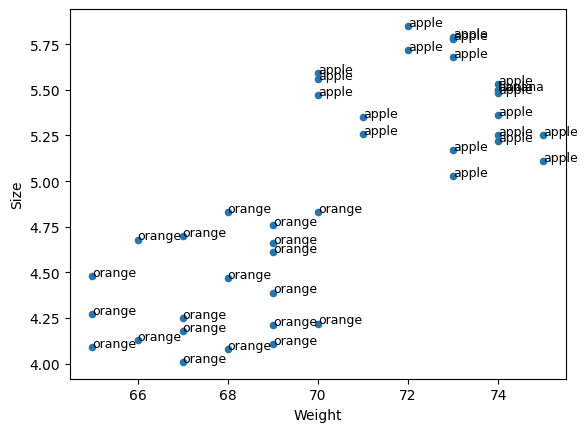

In [ ]:
chart = dataframe.plot.scatter(x="Weight", y="Size")
for i, label in enumerate(dataframe['Label']):
    chart.text(dataframe['Weight'][i], dataframe['Size'][i], label, fontsize=9)

But lets get into throwing some machine learning at this. We're going to use `scikitlearn` and its decision `tree` algorithm.

In [ ]:
from sklearn import tree
model = tree.DecisionTreeClassifier()

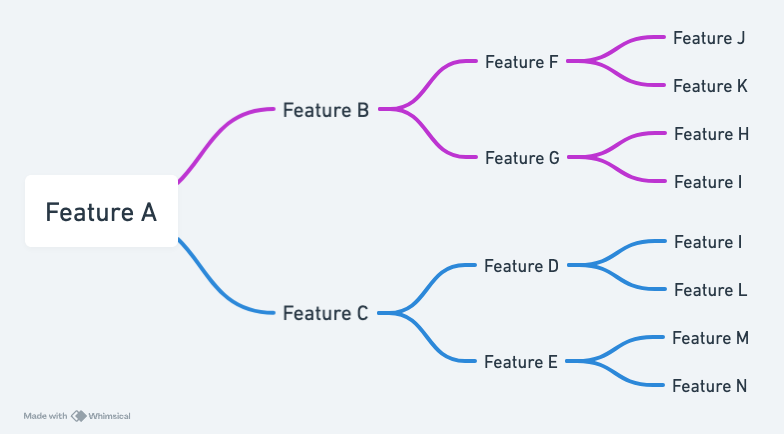

Then we `fit` the `features` and `labels` to the algorithm we chose.

In [ ]:
features = dataframe[columns[:-1]].to_numpy()
labels = dataframe['Label'].to_numpy()
print(labels)
model = model.fit(features, labels)

['orange' 'orange' 'orange' 'apple' 'orange' 'apple' 'apple' 'apple'
 'apple' 'orange' 'apple' 'apple' 'apple' 'orange' 'apple' 'orange'
 'orange' 'apple' 'orange' 'apple' 'orange' 'orange' 'orange' 'orange'
 'orange' 'apple' 'orange' 'orange' 'apple' 'apple' 'apple' 'orange'
 'apple' 'apple' 'orange' 'orange' 'orange' 'apple' 'apple' 'apple'
 'banana']


Now say I have a fruit in my hand that is 70 in weight and 4 in size, what kind of fruit is it? Is it an apple or an orange?

In [ ]:
inference_sample = [[70, 4]]
print(model.predict(inference_sample))

['orange']


*What* about another fruit?

In [ ]:
inference_sample = [[70, 6]]
print(model.predict(inference_sample))

['apple']


And 70 and 5.5?

In [ ]:
inference_sample = [[70, 5.5]]
print(model.predict(inference_sample))

['apple']


But hang on. That last fruit I had in my hand was a banana! 🍌

The farm's sorting line was contaminated with a fruit it wasn't expecting and now the bin of apples has a banana in it. What do we do?

We add another feature. If a banana is typically the same size and weight as an apple and not an orange then what else can distinguish the new fruit? You might think of `colour` but bananas can be green and there are yellow apples and yellow oranges too. How about `shape`? 🟢 vs 🪃 shape.

In [ ]:
columns = ["Weight", "Size", "Shape", "Label"]
samples = numpy.array(
        [
            [69, 4.39, 0, "orange"],
            [69, 4.21, 0, "orange"],
            [65, 4.09, 0, "orange"],
            [72, 5.85, 0, "apple"],
            [67, 4.7, 1, "banana"],
            [73, 5.68, 0, "apple"],
            [70, 5.56, 0, "apple"],
            [75, 5.11, 0, "apple"],
            [74, 5.36, 1, "banana"],
            [65, 4.27, 0, "orange"],
            [73, 5.79, 0, "apple"],
            [70, 5.47, 1, "banana"],
            [74, 5.53, 0, "apple"],
            [68, 4.47, 1, "banana"],
            [74, 5.22, 0, "apple"],
            [65, 4.48, 0, "orange"],
            [69, 4.66, 0, "orange"],
            [75, 5.25, 0, "apple"],
            [67, 4.18, 0, "orange"],
            [74, 5.5, 1, "banana"],
            [66, 4.13, 0, "orange"],
            [70, 4.83, 0, "orange"],
            [69, 4.61, 1, "banana"],
            [68, 4.08, 0, "orange"],
            [67, 4.25, 0, "orange"],
            [71, 5.35, 0, "apple"],
            [67, 4.01, 0, "orange"],
            [70, 4.22, 0, "orange"],
            [74, 5.25, 0, "apple"],
            [71, 5.26, 1, "banana"],
            [73, 5.78, 0, "apple"],
            [66, 4.68, 1, "banana"],
            [72, 5.72, 0, "apple"],
            [73, 5.17, 0, "apple"],
            [68, 4.83, 0, "orange"],
            [69, 4.11, 0, "orange"],
            [69, 4.76, 0, "orange"],
            [74, 5.48, 0, "apple"],
            [70, 5.59, 1, "banana"],
            [73, 5.03, 0, "apple"],
        ]
    )

dataframe = pandas.DataFrame(
    samples,
    columns=columns,
).astype({"Weight": "int64", "Size": "float64", "Shape": "int64", "Label": "object"})

Lets plot it and notice that you can no longer see the discriminating line.

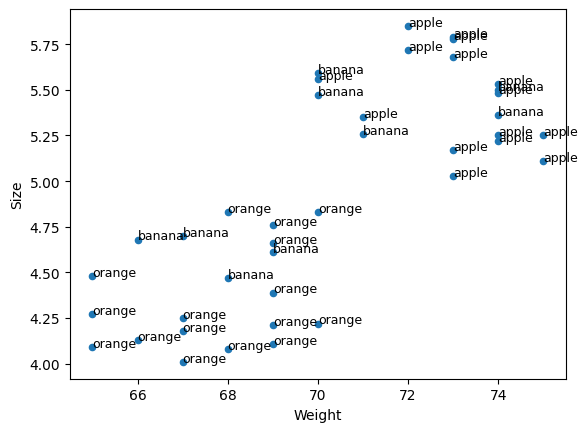

In [ ]:
chart = dataframe.plot.scatter(x="Weight", y="Size")
for i, label in enumerate(dataframe['Label']):
    chart.text(dataframe['Weight'][i], dataframe['Size'][i], label, fontsize=9)

Now rebuild the model.

In [ ]:
features = dataframe[columns[:-1]].to_numpy()
labels = dataframe['Label'].to_numpy()
model = tree.DecisionTreeClassifier()
model = model.fit(features, labels)

Now lets try infer with our banana again.

In [ ]:
inference_sample = [[70,1, 5.5]]
print(model.predict(inference_sample))

['banana']


That's great, it worked. In the real world though objects have dozens if not hundreds of features. So lets run a quick example using random data just to demonstrate.

In [ ]:
number_of_features = 784
number_of_samples = 1000
feature_range = 255

random_number_generator = numpy.random.default_rng()
columns = list(range(number_of_features))
columns.append("Label")
samples = random_number_generator.integers(0, feature_range, size=(number_of_samples, number_of_features+1))

dataframe = pandas.DataFrame(samples, columns=columns)
print(dataframe)

       0    1    2    3    4    5    6    7    8    9  ...  775  776  777  \
0     49   19  138  122   19  246   22  123  217  226  ...  143   87  137   
1    160  152  236  127  106   15   36   90   19   76  ...   51    7  105   
2     85   91  213  102  206  108  164  218  178  103  ...  182   80  150   
3    145  241  117  185   97   85  175   11  184   38  ...  198  144  114   
4      8  243    8  237  128    1  185   88  145  189  ...  225  106  103   
..   ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
995  246  245  227  218  198    0    5  226    9  238  ...   87   92  217   
996   24  153   47  137  119  206  178   32  150  103  ...  146   17   45   
997  251  135  231    5  202  243   91   46  212   18  ...   81   45   39   
998  114  174  210  237   17   94  228   90  233  165  ...  216  172   72   
999  167  172  171  136  235  225   46  101  151  133  ...  235  157  219   

     778  779  780  781  782  783  Label  
0     33  163  234  120   63   6

Plot it.

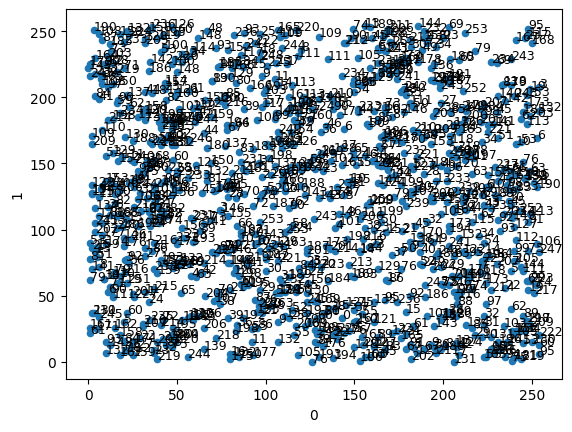

In [ ]:
chart = dataframe.plot.scatter(x=columns[0], y=columns[1])
for i, label in enumerate(dataframe['Label']):
    chart.text(dataframe[columns[0]][i], dataframe[columns[1]][i], label, fontsize=9)

Build the model.

In [ ]:
features = dataframe[columns[:-1]].to_numpy()
labels = dataframe['Label'].to_numpy()
model = tree.DecisionTreeClassifier()
model = model.fit(features, labels)

Get our inference sample.

In [ ]:
inference_sample = random_number_generator.integers(0, feature_range, size=(1, number_of_features))
print(inference_sample)


[[216 191 100  98 127 120 168 246  46 230 220  91  43 246 209  45 204  70
  222 140  26 170 240  52 200  11 185  66 220 173  42  91  47 166 252 110
  169 231  19 247  51  70 199  53 142 117  44 218 190 122 177  61 239 147
   51 210 148  24  63 234  62  58  48  49 152 245  71 211 153 164 138  87
   89  59 231 159 242  22  55  80 183 121  63  88  54 154  31 234  20 211
  149 188 220 166 169 246 215  31  41 191  90 201 246 141  62 247 136 200
   78  46 209 145 174 250  90 118  68 144  10  37 215 164  93  72 188 162
  187 164  32 147 115  62 214 140  12 133 201 229 168  43 104 213 233  38
    8   6 251 252 222  10 193 207 178 192 130 202  45   9  41  94 194 247
  102  82  43 103   3 170  30  77  98 175 117 166 133 221 201 169 184 198
  143 201 186  84  77   5  61 161 133 121  57 148 247  35 131   2 231 159
  182 157 171 165 209  21 126  56 130   0 122   2  36 123 126  20  78  23
   59 134  81  79  55  87 142  89 153 125 107 178  56 132 111  65  68  99
  134 140 196 131 185 235   0 111  84 

And infer.

In [ ]:
print(model.predict(inference_sample))

[78]


What might not be apparent here is that while the data is random and the labels unhelpful we're heading towards an algorithm that can deal with image data. Think of each feature as a gray scale pixel value (0 to 255) and each row, with 784 columns, as a labelled 28 by 28 image.

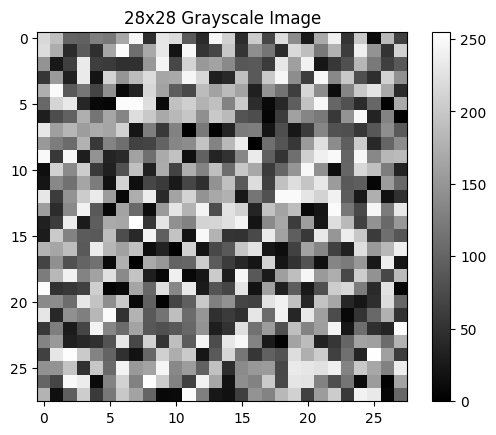

In [ ]:
import matplotlib.pyplot as pyplot
image_array = numpy.array(inference_sample).reshape((28, 28))
pyplot.imshow(image_array, cmap='gray', vmin=0, vmax=255)
pyplot.colorbar()
pyplot.title('28x28 Grayscale Image')
pyplot.show()
